# Notebook 02: Data Cleaning & Feature Engineering
Cleans the master dataset and engineers time-based and business features for analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load master dataset
df = pd.read_csv("../data/processed/master_data.csv", encoding="latin-1")

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
df.head(3)

Shape: (9994, 21)

Data types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [2]:
# Convert date columns to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Verify
print("Order Date dtype:", df["Order Date"].dtype)
print("Ship Date dtype:", df["Ship Date"].dtype)
print("\nDate range:", df["Order Date"].min(), "to", df["Order Date"].max())

Order Date dtype: datetime64[ns]
Ship Date dtype: datetime64[ns]

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


In [3]:
# Extract time-based features from Order Date
df["Year"]        = df["Order Date"].dt.year
df["Month"]       = df["Order Date"].dt.month
df["Quarter"]     = df["Order Date"].dt.quarter
df["MonthName"]   = df["Order Date"].dt.strftime("%b")
df["DayOfWeek"]   = df["Order Date"].dt.day_name()
df["YearMonth"]   = df["Order Date"].dt.to_period("M")

# Days to ship
df["DaysToShip"]  = (df["Ship Date"] - df["Order Date"]).dt.days

print("New columns added:")
print(["Year","Month","Quarter","MonthName","DayOfWeek","YearMonth","DaysToShip"])
df[["Order Date","Ship Date","Year","Month","Quarter","DaysToShip"]].head(5)

New columns added:
['Year', 'Month', 'Quarter', 'MonthName', 'DayOfWeek', 'YearMonth', 'DaysToShip']


,Order Date,Ship Date,Year,Month,Quarter,DaysToShip
0,2016-11-08,2016-11-11,2016,11,4,3
1,2016-11-08,2016-11-11,2016,11,4,3
2,2016-06-12,2016-06-16,2016,6,2,4
3,2015-10-11,2015-10-18,2015,10,4,7
4,2015-10-11,2015-10-18,2015,10,4,7


In [4]:
# Profit margin per row
df["ProfitMargin"] = (df["Profit"] / df["Sales"]).round(4)

# Revenue sanity check (Sales is already revenue in this dataset)
# Flag rows where discount is unusually high
df["HighDiscount"] = df["Discount"] >= 0.5

print("High discount rows:", df["HighDiscount"].sum())
print("\nProfit Margin stats:\n", df["ProfitMargin"].describe())

High discount rows: 922

Profit Margin stats:
 count    9994.000000
mean        0.120314
std         0.466754
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: ProfitMargin, dtype: float64


In [5]:
# Check for negative profits (loss-making orders)
df_losses = df[df["Profit"] < 0]
print("Loss-making rows:", len(df_losses))
print("Total loss amount: $", round(df_losses["Profit"].sum(), 2))
print("\nLoss by Category:")
print(df_losses.groupby("Category")["Profit"].sum().round(2))

Loss-making rows: 1871
Total loss amount: $ -156131.29

Loss by Category:
Category
Furniture         -60936.11
Office Supplies   -56615.26
Technology        -38579.92
Name: Profit, dtype: float64


In [6]:
# Outlier detection on Sales using IQR
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["SalesOutlier"] = (df["Sales"] < lower) | (df["Sales"] > upper)

print(f"Sales IQR bounds: ${lower:.2f} to ${upper:.2f}")
print(f"Sales outlier rows: {df['SalesOutlier'].sum()}")
df[df["SalesOutlier"] == True][["Order ID","Product Name","Sales","Category"]].head(5)

Sales IQR bounds: $-271.71 to $498.93
Sales outlier rows: 1167


,Order ID,Product Name,Sales,Category
1,CA-2016-152156,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,Furniture
3,US-2015-108966,Bretford CR4500 Series Slim Rectangular Table,957.5775,Furniture
7,CA-2014-115812,Mitel 5320 IP Phone VoIP phone,907.1520,Technology
10,CA-2014-115812,Chromcraft Rectangular Conference Tables,1706.1840,Furniture
11,CA-2014-115812,Konftel 250 ConferenceÂ phoneÂ - Charcoal black,911.4240,Technology


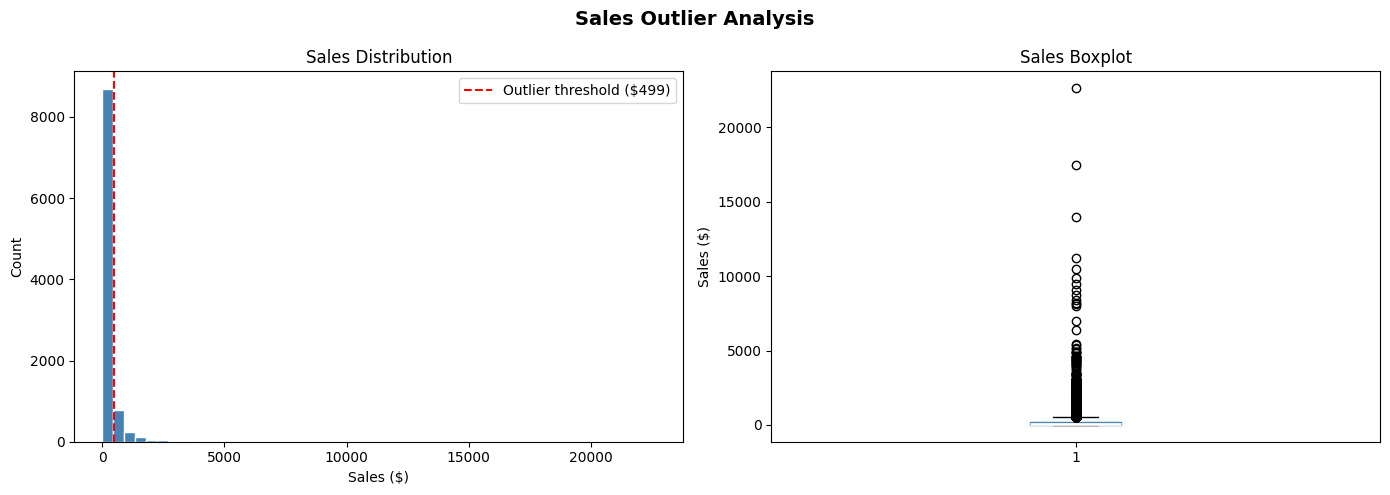

Chart saved.


In [7]:
# Visualize Sales distribution with outlier threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["Sales"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(upper, color="red", linestyle="--", label=f"Outlier threshold (${upper:.0f})")
axes[0].set_title("Sales Distribution")
axes[0].set_xlabel("Sales ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
axes[1].boxplot(df["Sales"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", color="steelblue"),
                medianprops=dict(color="white", linewidth=2))
axes[1].set_title("Sales Boxplot")
axes[1].set_ylabel("Sales ($)")

plt.suptitle("Sales Outlier Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
os.makedirs("../outputs/figures", exist_ok=True)
plt.savefig("../outputs/figures/sales_outlier_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [8]:
# Final cleaned dataset summary
print("Final shape:", df.shape)
print("\nNew columns:", ["Year","Month","Quarter","MonthName","DayOfWeek",
                         "YearMonth","DaysToShip","ProfitMargin",
                         "HighDiscount","SalesOutlier"])
print("\nNull check on new columns:")
new_cols = ["Year","Month","Quarter","DaysToShip","ProfitMargin","HighDiscount","SalesOutlier"]
print(df[new_cols].isnull().sum())

Final shape: (9994, 31)

New columns: ['Year', 'Month', 'Quarter', 'MonthName', 'DayOfWeek', 'YearMonth', 'DaysToShip', 'ProfitMargin', 'HighDiscount', 'SalesOutlier']

Null check on new columns:
Year            0
Month           0
Quarter         0
DaysToShip      0
ProfitMargin    0
HighDiscount    0
SalesOutlier    0
dtype: int64


In [9]:
# Save cleaned dataset
df.to_csv("../data/processed/cleaned_data.csv", index=False)
print("cleaned_data.csv saved to data/processed/")

cleaned_data.csv saved to data/processed/
